## Individuell inlämningsuppgift – Deep Learning

# Marcus Bäckström


In [26]:
# Grundläggande bibliotek
import time

import os
from PIL import Image

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
train_dir = "Data/train"
test_dir = "Data/test"

# Funktions

In [4]:
def load_images_from_folder(dir, image_size=(48, 48), max_per_class = None ):

    X = []
    y = []
    class_names = sorted(os.listdir(dir))

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)

        if  max_per_class is not None:
            images = images[:max_per_class]

        for img_file in images:
            img_path = os.path.join(class_path, img_file)

            try:
                img = Image.open(img_path).convert("L") # Convert to grayscale in case they are not grayscale.
                img = img.resize(image_size)
                X.append(np.array(img))
                y.append(label)
            except:
                pass
    


    return  np.array(X), np.array(y), class_names

In [ ]:
def plot_image_grid(X,y, class_names, n_images=25, random_state=42, afigsize=(12, 12) ):

    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images) ) )

    plt.figure(figsize=afigsize)

    for plot_index, image_index in enumerate(indices):
        
        plt.subplot(grid_size, grid_size, plot_index + 1)

        plt.imshow(X[image_index], cmap="gray")

        plt.title(class_names[y[image_index] ], fontsize=9 )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [38]:
def plot_history(history, title="", afigsize=(12, 4) ):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=afigsize)

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training Loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation Loss")

    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")

    plt.ylim(0,3)
    plt.xlim(1, len(history_df) )

    plt.legend()

    plt.suptitle(title)
    
    plt.figure(figsize=afigsize )

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["accuracy"], label="Training Accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation Accuracy")

    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")

    plt.ylim(0,3)
    plt.xlim(1, len(history_df) )

    plt.legend()

    plt.suptitle(title)

    plt.tight_layout()
    plt.show()

# Early peek at the Data

In [5]:
class_names_train = sorted(os.listdir(train_dir))
print(f"Train Klasser : {class_names_train}")
class_names_test = sorted(os.listdir(test_dir))
print(f"Test Klasser : {class_names_test}")

Train Klasser : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test Klasser : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
class_distribution_train = pd.DataFrame({
    "train_class_name": class_names_train,
    "count": [len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names_train]
})

class_distribution_test = pd.DataFrame({
    "test_class_name": class_names_test,
    "count": [len(os.listdir(os.path.join(test_dir, cls))) for cls in class_names_test]
})

display(class_distribution_train)
display(class_distribution_test)

,train_class_name,count
0,angry,3995
1,disgust,436
2,fear,4097
3,happy,7215
4,neutral,4965
5,sad,4830
6,surprise,3171


,test_class_name,count
0,angry,958
1,disgust,111
2,fear,1024
3,happy,1774
4,neutral,1233
5,sad,1247
6,surprise,831


In [7]:
print("Totalt antal träningsbilder:", class_distribution_train["count"].sum())
print("Totalt antal testbilder:", class_distribution_test["count"].sum())


Totalt antal träningsbilder: 28709
Totalt antal testbilder: 7178


# Load image: 

## Small batch

In [8]:

X_train_full, y_train_full, class_names = load_images_from_folder(
    train_dir, 
    max_per_class=300
)

print(f"X_train_full Shape : {X_train_full.shape}")
print(f"y_train_full Shape : {y_train_full.shape}")
print(f"Class Names : {class_names}")

X_train_full Shape : (2100, 48, 48)
y_train_full Shape : (2100,)
Class Names : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


# Check Loaded Images

In [ ]:
class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

In [ ]:
plot_image_grid(
    X=X_train_full,
    y=y_train_full,
    class_names=class_names,
    n_images=25
)

In [ ]:
print("Minsta pixel värde : ", X_train_full.min())
print("Största pixel värde : ", X_train_full.max())

unika labels :  [0 1 2 3 4 5 6]
Minsta pixel värde :  0
Största pixel värde :  255


# Train Val 

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    random_state=42,
    test_size=0.10,
    stratify=y_train_full
)

print(f"X_train Shape :  {X_train.shape}")
print(f"y_train Shape :  {y_train.shape}")
print(f"X_val Shape :  {X_val.shape}")
print(f"y_val Shape :  {y_val.shape}")


X_train Shape :  (1890, 48, 48)
y_train Shape :  (1890,)
X_val Shape :  (210, 48, 48)
y_val Shape :  (210,)


# Format/Scale data

In [17]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

In [18]:
# add channel as cnn model need 3 vector, X, Y, Z.
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]

print("X_train Shape efter kanal-dimension", X_train.shape)
print("X_val Shape efter kanal-dimension", X_val.shape)


X_train Shape efter kanal-dimension (1890, 48, 48, 1)
X_val Shape efter kanal-dimension (210, 48, 48, 1)


# Begin Models

### Baseline Model

In [27]:

baseline_model = keras.Sequential([

    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(2, 2),

    
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),


    layers.Dense(10, activation="softmax")

])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,354 (2.32 MB)

 Trainable params: 609,354 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [29]:
baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.1598 - loss: 1.9964 - val_accuracy: 0.1619 - val_loss: 1.9395
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.2079 - loss: 1.9133 - val_accuracy: 0.1714 - val_loss: 1.8804
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.2698 - loss: 1.8211 - val_accuracy: 0.2714 - val_loss: 1.8449
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.3169 - loss: 1.7360 - val_accuracy: 0.3238 - val_loss: 1.8360
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.3698 - loss: 1.6432 - val_accuracy: 0.3190 - val_loss: 1.8559


# Plot baseline

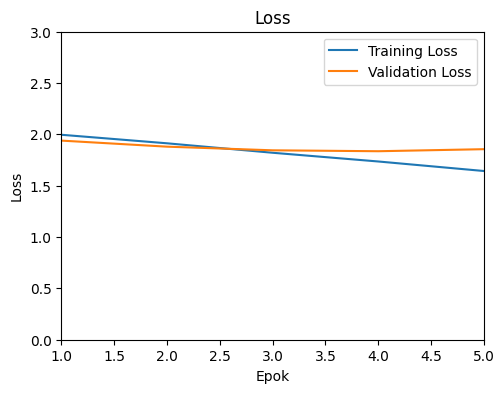

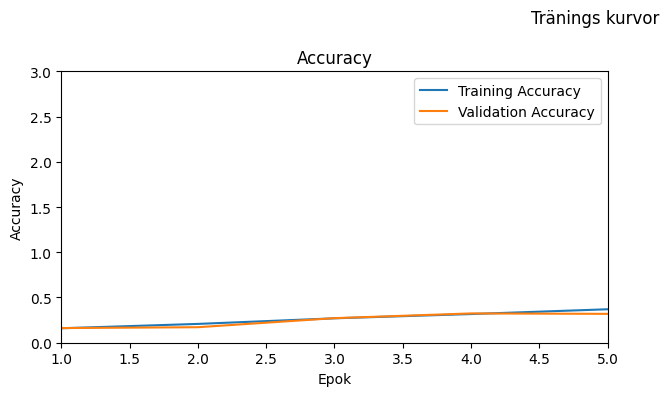

In [30]:
plot_history(baseline_history)

# Save Model & History

In [36]:
baseline_model.save("Models/baseline_model.keras")

In [37]:
loaded_baseline_model = keras.models.load_model("Models/baseline_model.keras")

In [31]:
with open("Histories/baseline_history.json", "w") as f:
    json.dump(baseline_history.history, f)

In [33]:
with open("Histories/baseline_history.json", "r") as f:
    baseline_history_data = json.load(f)

In [34]:
class FakeHistory:
    def __init__(self, history_dict):
        self.history = history_dict

loaded_baseline_history = FakeHistory(baseline_history_data)

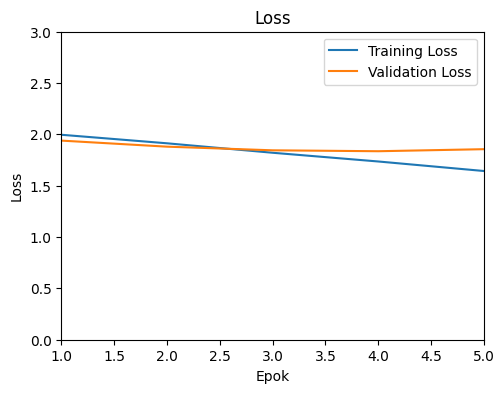

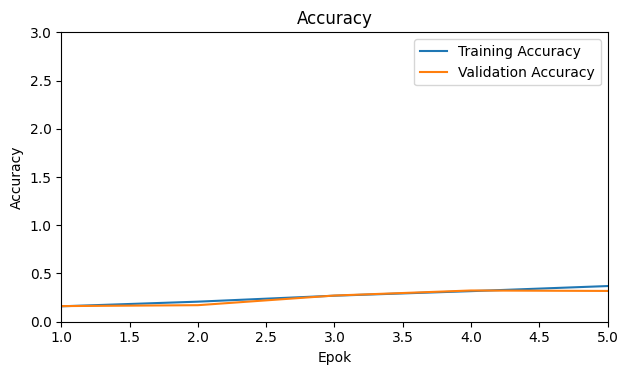

In [39]:
plot_history(loaded_baseline_history)